<a href="https://colab.research.google.com/github/aartip0325-cmd/AartiPanda/blob/main/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [ ]:
# Breast Cancer Wisconsin (Diagnostic) dataset is built into sklearn
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
print("\nTarget classes:", data.target_names)
print("\nClass distribution:\n", df['target'].value_counts())

df.head()

Shape of dataset: (569, 31)

Target classes: ['malignant' 'benign']

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nStatistical summary:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

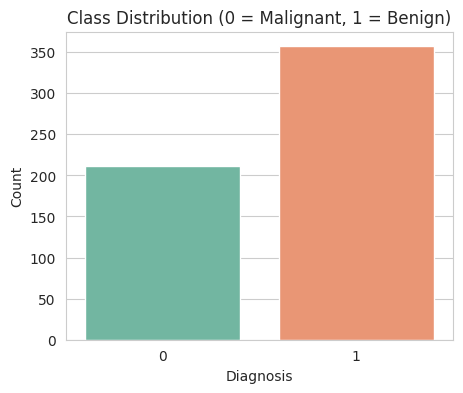

In [ ]:
# Class distribution plot
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

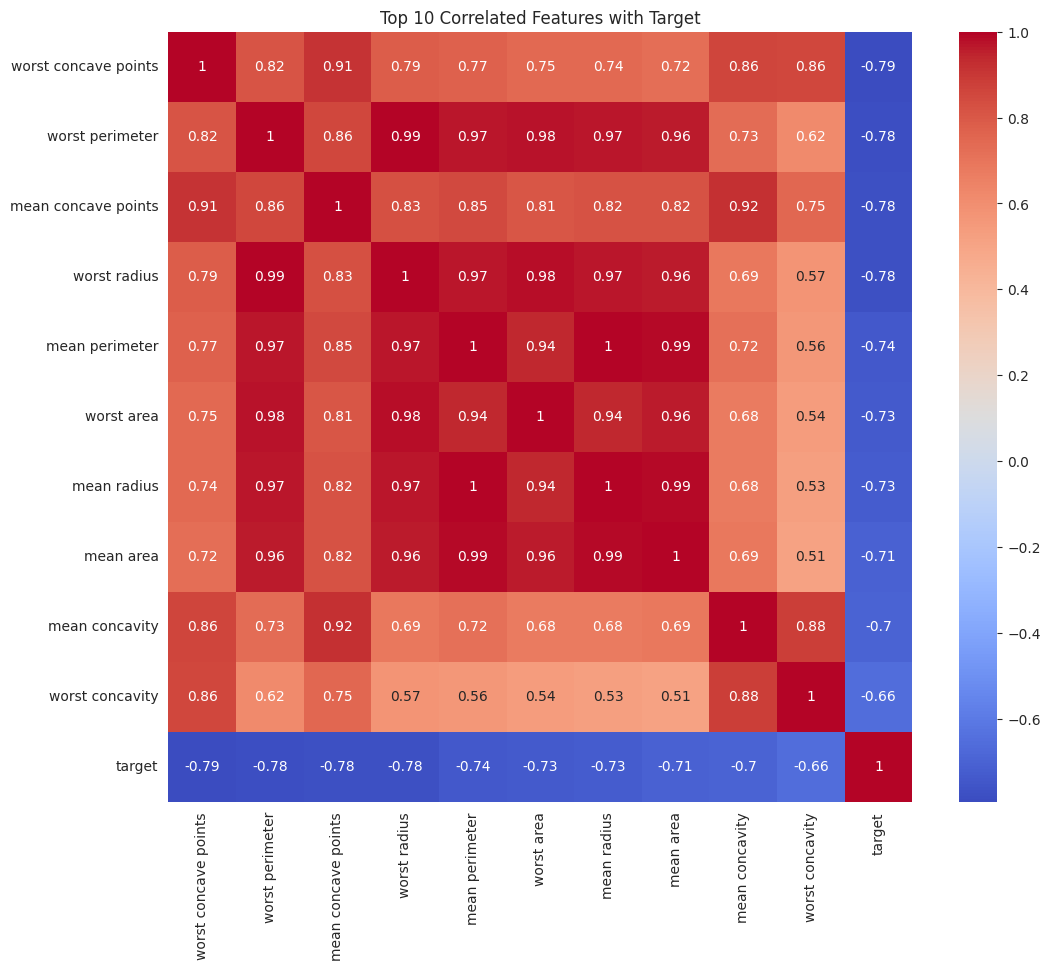

In [ ]:
# Correlation heatmap (top correlated features with target)
plt.figure(figsize=(12,10))
corr = df.corr()
top_corr_features = corr['target'].abs().sort_values(ascending=False)[1:11].index
sns.heatmap(df[top_corr_features.tolist() + ['target']].corr(), annot=True, cmap='coolwarm')
plt.title("Top 10 Correlated Features with Target")
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


In [ ]:
# Logistic Regression, SVM, and KNN are distance/gradient based -> scaling is essential
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [ ]:
results = []

for name, model in models.items():
    # Tree-based models (RF, GB) don't strictly need scaling, but using scaled data
    # everywhere keeps the comparison consistent and doesn't hurt them.
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df


===== Logistic Regression =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== SVM =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== Random Forest =====
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       1

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,SVM,0.982456,0.986111,0.986111,0.986111
2,Gradient Boosting,0.956140,0.946667,0.986111,0.965986
3,Random Forest,0.956140,0.958904,0.972222,0.965517
4,KNN,0.956140,0.958904,0.972222,0.965517


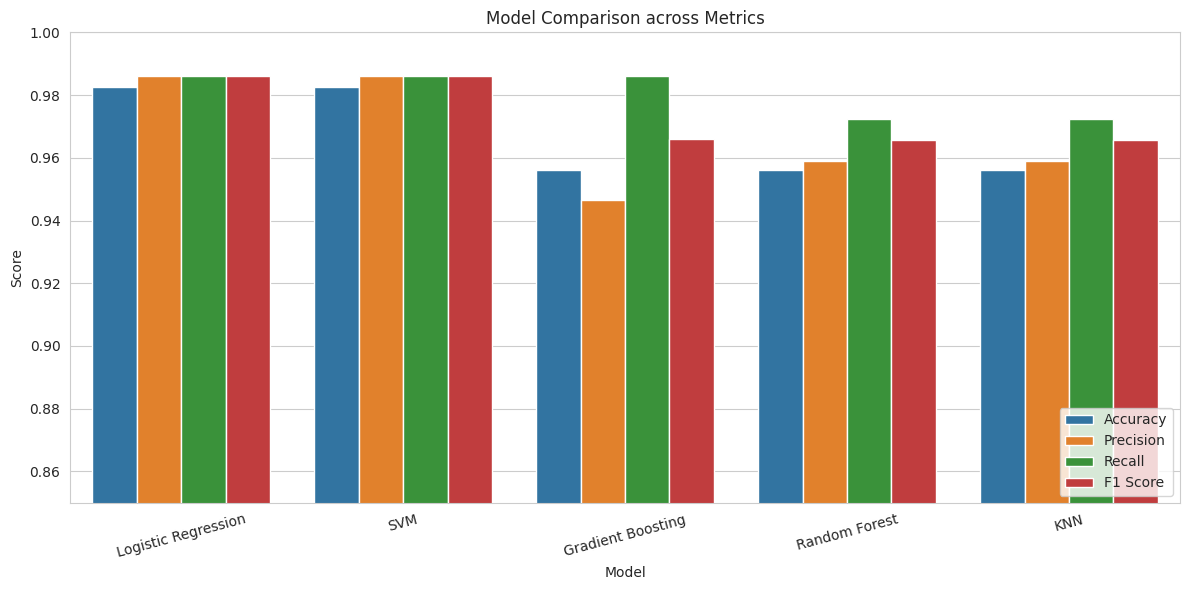

In [ ]:
results_melted = results_df.melt(id_vars="Model",
                                  value_vars=["Accuracy","Precision","Recall","F1 Score"],
                                  var_name="Metric", value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison across Metrics")
plt.xticks(rotation=15)
plt.ylim(0.85, 1.0)   # zoom in since breast cancer models usually score high
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

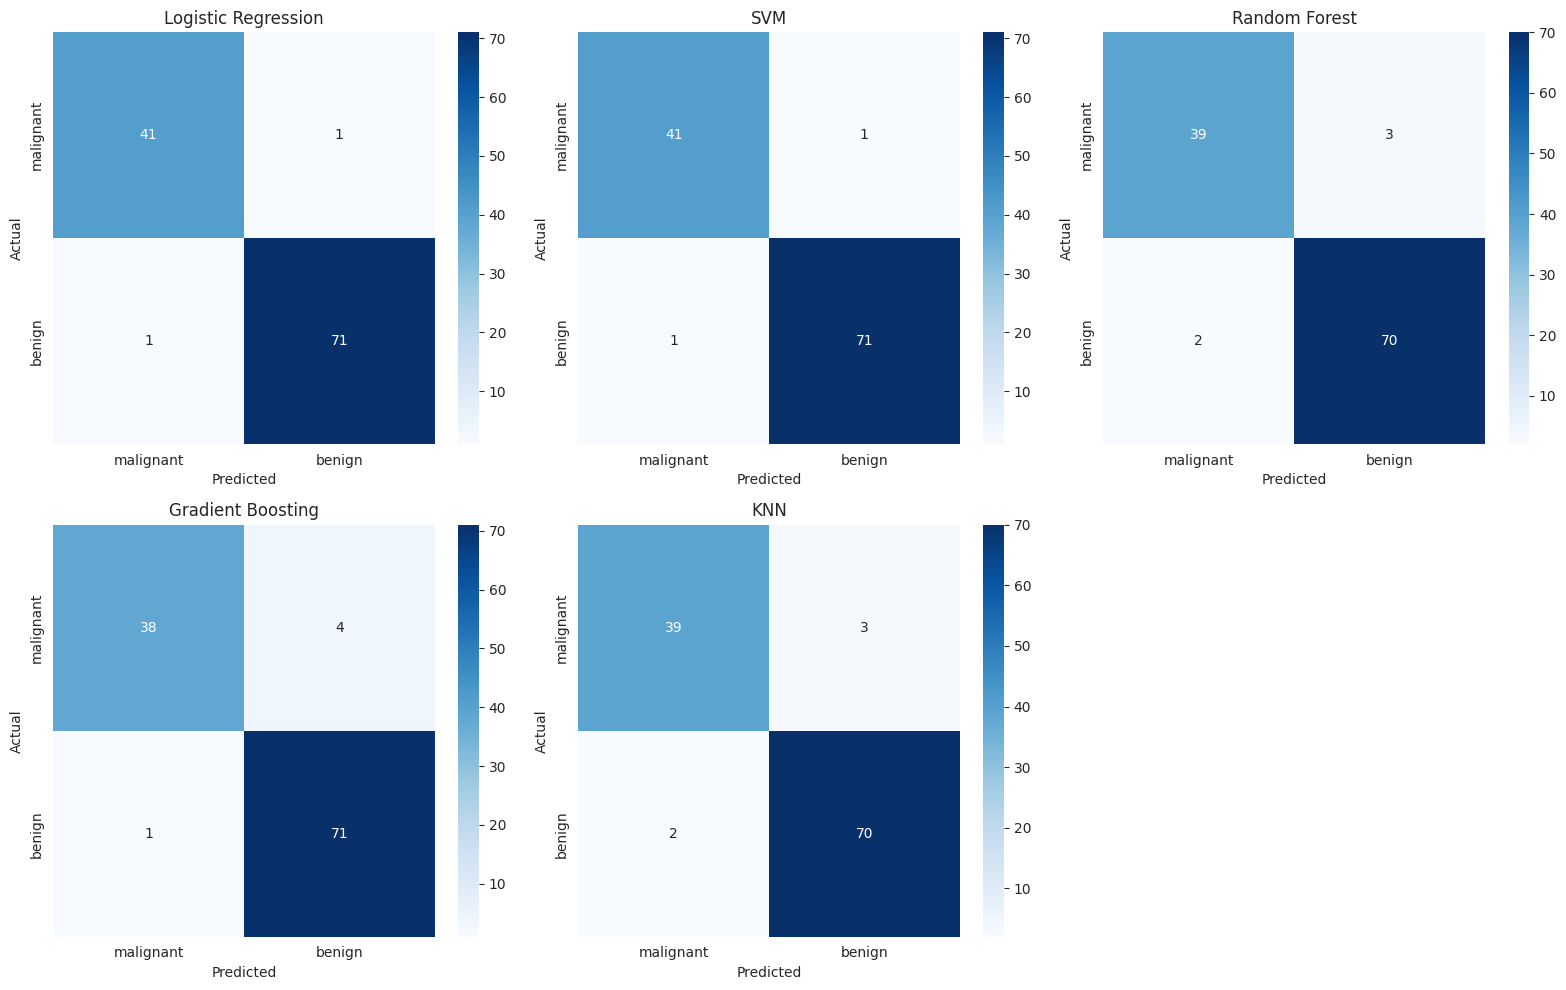

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names, yticklabels=data.target_names,
                ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

fig.delaxes(axes[5])  # remove the empty 6th subplot
plt.tight_layout()
plt.show()

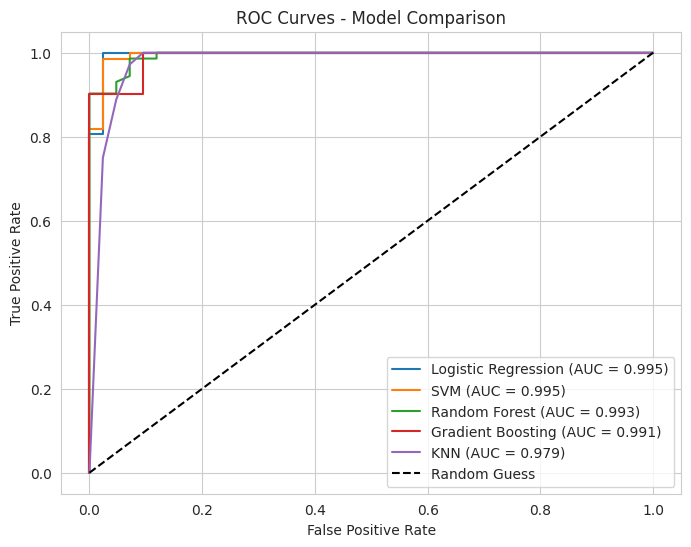

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc='lower right')
plt.show()

In [ ]:
best_model_row = results_df.iloc[0]
print("Final Results Table:\n")
print(results_df.to_string(index=False))

print(f"\n🏆 Best performing model: {best_model_row['Model']}")
print(f"   Accuracy : {best_model_row['Accuracy']:.4f}")
print(f"   Precision: {best_model_row['Precision']:.4f}")
print(f"   Recall   : {best_model_row['Recall']:.4f}")
print(f"   F1 Score : {best_model_row['F1 Score']:.4f}")

print("""
Note for medical datasets:
In a medical diagnosis context (like cancer detection), RECALL for the
'malignant' class is often the most critical metric — missing a cancer
case (false negative) is far more dangerous than a false alarm
(false positive). So while overall accuracy/F1 matters, also specifically
check recall on the malignant class when deciding which model is "best"
for this use case.
""")

Final Results Table:

              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.982456   0.986111 0.986111  0.986111
                SVM  0.982456   0.986111 0.986111  0.986111
  Gradient Boosting  0.956140   0.946667 0.986111  0.965986
      Random Forest  0.956140   0.958904 0.972222  0.965517
                KNN  0.956140   0.958904 0.972222  0.965517

🏆 Best performing model: Logistic Regression
   Accuracy : 0.9825
   Precision: 0.9861
   Recall   : 0.9861
   F1 Score : 0.9861

Note for medical datasets:
In a medical diagnosis context (like cancer detection), RECALL for the
'malignant' class is often the most critical metric — missing a cancer
case (false negative) is far more dangerous than a false alarm
(false positive). So while overall accuracy/F1 matters, also specifically
check recall on the malignant class when deciding which model is "best"
for this use case.

